##Problem Statement:

The objective of this project is to segment customers based on their demographic and spending behavior using clustering techniques.

This helps businesses design targeted marketing strategies, improve customer retention, and increase revenue.

##Import Libraries

In [1]:
# Import required libraries for data analysis and visualization

import pandas as pd              # For data manipulation and analysis (DataFrames)
import numpy as np               # For numerical operations and array computations
import matplotlib.pyplot as plt  # For creating basic visualizations (plots, charts)
import seaborn as sns            # For advanced statistical data visualization

from sklearn.preprocessing import StandardScaler  # For scaling features (normalizing data for KMeans)
from sklearn.cluster import KMeans                # K-Means clustering algorithm for customer segmentation
from sklearn.metrics import silhouette_score      # For evaluating clustering performance (cluster quality)

# Set style for better visuals
sns.set(style="whitegrid")

# Set random seed for reproducibility (ensures same results every run)
np.random.seed(42)

##Data Loading

We begin by importing the dataset containing customer demographic and spending information.

This dataset will be used to identify patterns and group similar customers together.

In [2]:
# Load dataset from CSV file (contains customer demographics and spending behavior)
df = pd.read_csv("/content/Mall_Customers.csv")

# Display first 5 rows of the dataset
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##Data Validation

Perform data validation to understand the structure, quality, and consistency of the dataset.

   - shape
   - info
   - null values
   - duplicates
   - nunique
   - data types
   - describes
   - columns

This section ensures the data quality is good before analysis.

In [3]:
# Print dataset size (number of rows and columns)
print("Dataset Shape (Rows, Columns):", df.shape)

Dataset Shape (Rows, Columns): (200, 5)


In [4]:
# Display information about columns
# Shows column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Check for missing values in each column
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
# Check if duplicate rows exist in the dataset
df.duplicated().sum()

np.int64(0)

In [7]:
# Count the number of unique values in each column
df.nunique()

,0
CustomerID,200
Gender,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


In [8]:
# Display data types of all columns
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [9]:
# Show summary statistics of numerical columns
# Includes mean, std, min, max, etc.
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
# Display all column names in the dataset
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

##Data Cleaning

In [11]:
# Create a copy of the original dataset
# This ensures the raw dataset remains unchanged
df1 = df.copy()

# Rename the columns for clear understanding
df1.rename(columns={'Annual Income (k$)': 'Annual Income', 'Spending Score (1-100)': 'Spending Score'}, inplace=True)

##Exploratory Data Analysis (EDA)

###Gender Distribution

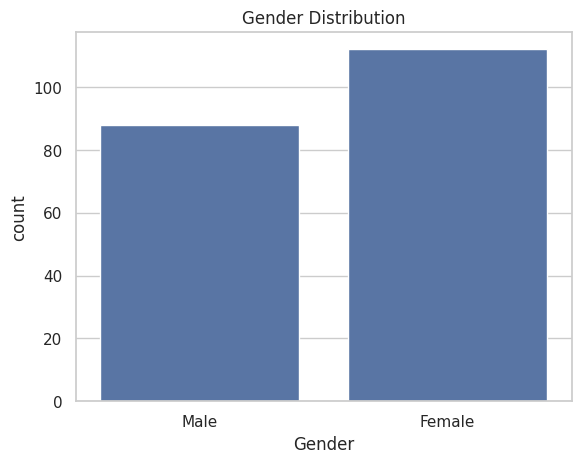

In [12]:
# Count of customers by gender
sns.countplot(x='Gender', data=df1)
plt.title("Gender Distribution")
plt.show()

###Age Distribution

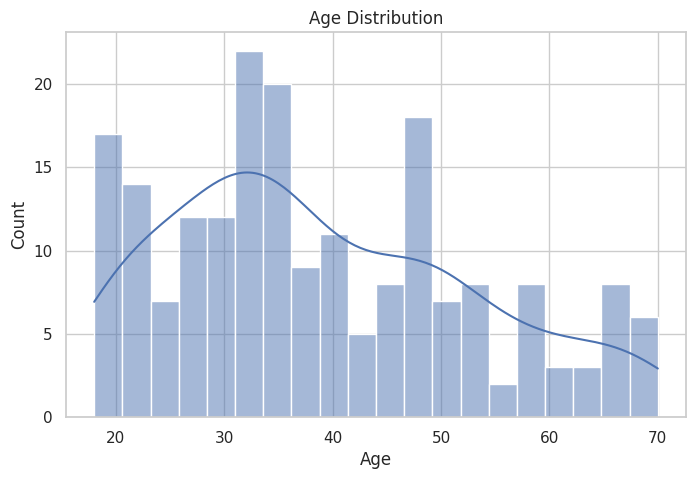

In [13]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df1['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

###Annual Income Distribution

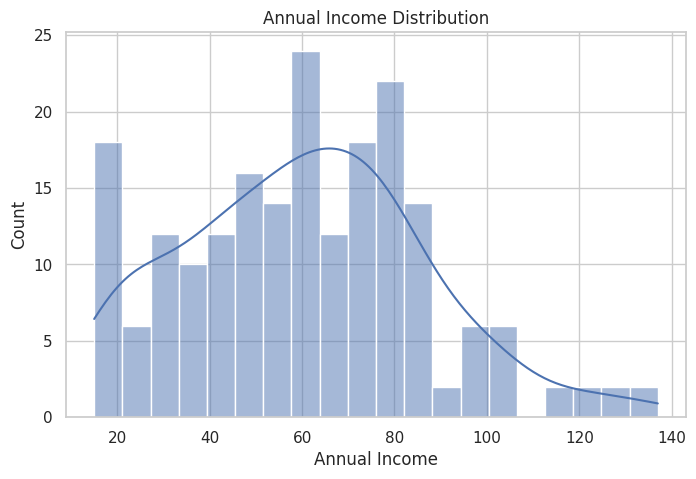

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df1['Annual Income'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

###Spending Score Distribution

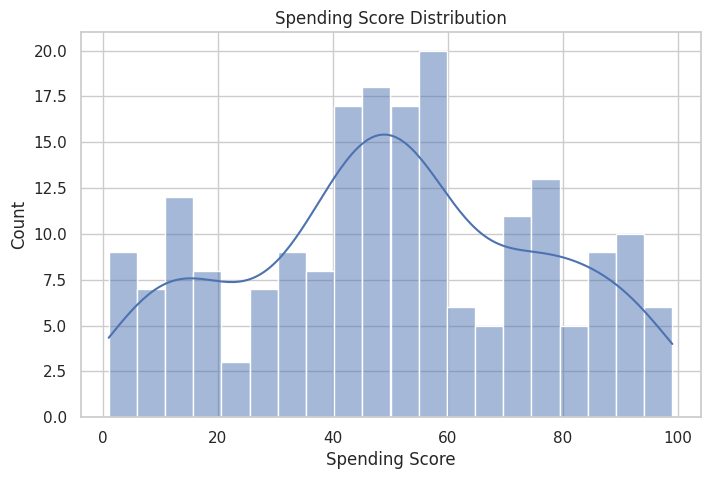

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df1['Spending Score'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

###Income vs Spending

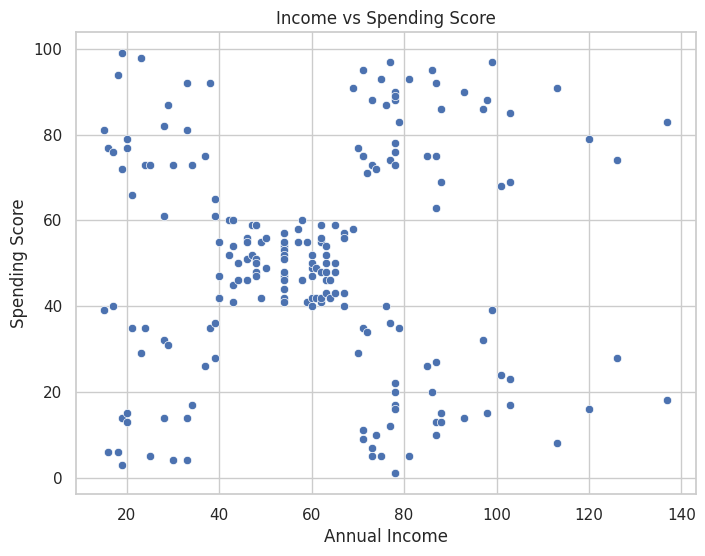

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income',
    y='Spending Score',
    data=df1
)
plt.title("Income vs Spending Score")
plt.show()

###Correlation Heatmap

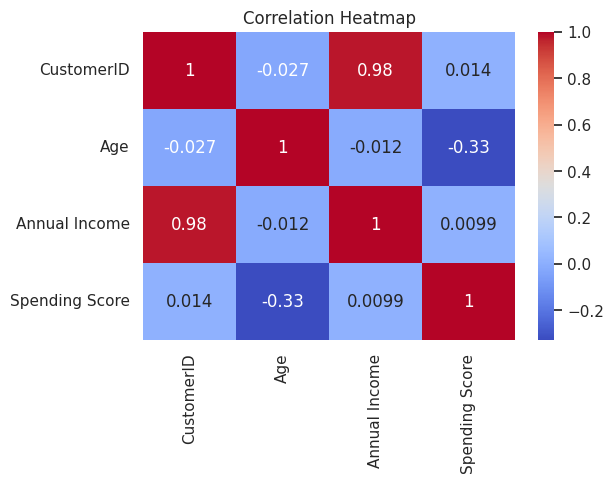

In [17]:
# Correlation matrix
corr = df1.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The analysis shows clear patterns between income and spending behavior, indicating the presence of distinct customer groups.

This justifies the use of clustering techniques like K-Means for segmentation.

##Feature Selection + Scaling

###Feature Selection

In [18]:
# Select relevant features for clustering (income and spending define customer behavior)
X = df1[['Annual Income', 'Spending Score']]

# Display first few rows
X.head()

,Annual Income,Spending Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


###Feature Scaling

In [19]:
# Initialize StandardScaler to normalize feature values
scaler = StandardScaler()

# Scale features to ensure equal importance (KMeans uses distance-based calculation)
X_scaled = scaler.fit_transform(X)

###Finding Optimal Clusters (Elbow Method)

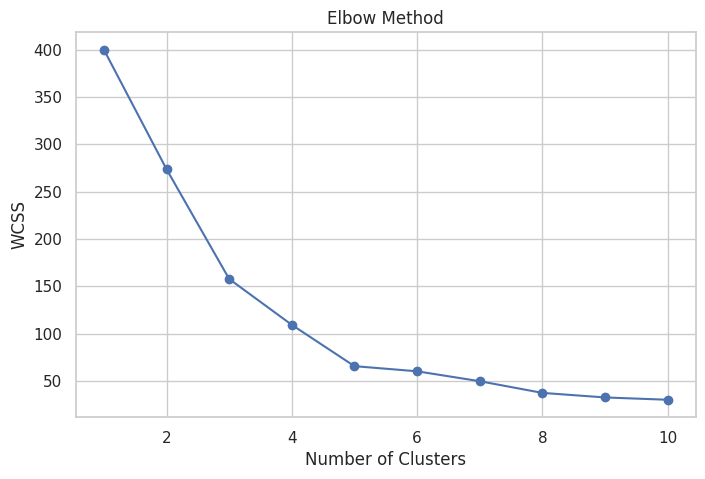

<Figure size 640x480 with 0 Axes>

In [20]:
wcss = []  # Within-Cluster Sum of Squares

# Calculate WCSS for different cluster values to find optimal number of clusters
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()
plt.savefig("elbow_method.png", bbox_inches='tight')

Store WCSS values for different cluster sizes to identify optimal k using elbow method.

The elbow point is observed at k = 5, where the rate of decrease in WCSS begins to slow down.

###Apply K-Means Clustering

In [21]:
# Initialize KMeans model with optimal number of clusters (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)

# Assign each data point to a cluster
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset for analysis
df1['Cluster'] = y_kmeans

###Visualize Clusters

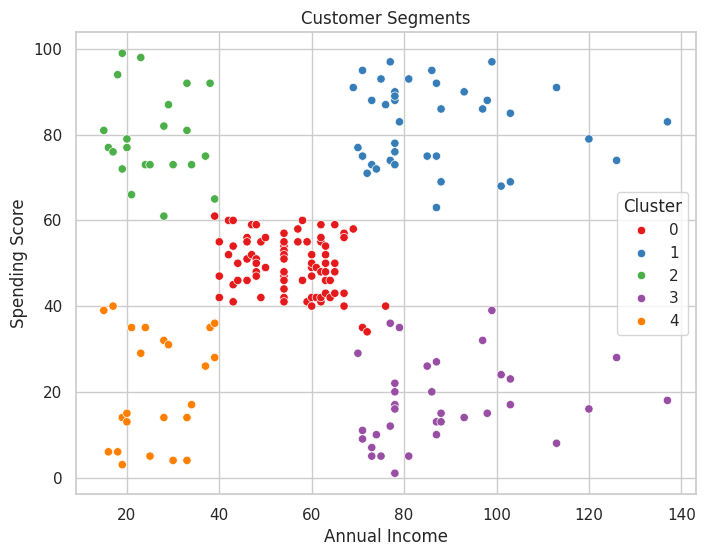

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income',
    y='Spending Score',
    hue='Cluster',
    palette='Set1',
    data=df1
)

plt.title("Customer Segments")
plt.show()

This segmentation enables businesses to design targeted marketing strategies, optimize resource allocation, and improve customer retention.

###Cluster Profiling

In [23]:
# Analyze average characteristics of each cluster to understand customer segments
cluster_summary = df1.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean()

print("Cluster Summary (Mean Values):")
cluster_summary

Cluster Summary (Mean Values):


,Age,Annual Income,Spending Score
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


###Cluster Size

In [24]:
# Number of customers in each cluster
cluster_size = df1['Cluster'].value_counts().sort_index()

print("\nCluster Size:")
cluster_size


Cluster Size:


,count
Cluster,
0,81
1,39
2,22
3,35
4,23


###Combine Everything

In [25]:
# Combine mean values and customer count to create a complete cluster profile
cluster_profile = df1.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income': 'mean',
    'Spending Score': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Customer Count'})

print("\nFinal Cluster Profile:")
cluster_profile


Final Cluster Profile:


,Age,Annual Income,Spending Score,Customer Count
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


##Model Evaluation + Justification

###Silhouette Score

In [26]:
# Evaluate clustering performance using Silhouette Score (measures cluster separation and cohesion)
sil_score = silhouette_score(X_scaled, y_kmeans)

print("Silhouette Score:", round(sil_score, 3))

Silhouette Score: 0.555


###Comparison for Multiple K

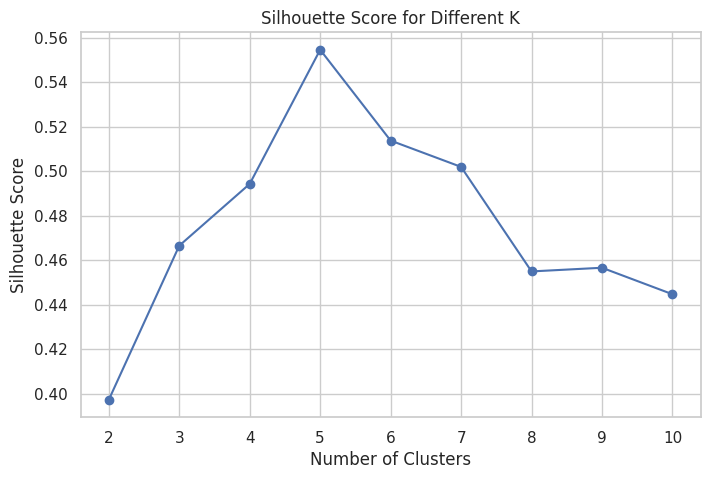

<Figure size 640x480 with 0 Axes>

In [27]:
silhouette_scores = []

# Compare silhouette scores for different cluster values to validate optimal k
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

plt.savefig("silhouette_score.png", bbox_inches='tight')

Higher silhouette score indicates better-defined and well-separated clusters.

##Advanced Visualizations

###Plot Cluster Centroids

In [28]:
# Refit KMeans model with optimal clusters to correctly compute centroids
kmeans_final = KMeans(n_clusters=5, random_state=42)

kmeans_final.fit(X_scaled)

# Transform centroids back to original scale for interpretation
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)

# Convert to DataFrame for easy plotting
centroids_df = pd.DataFrame(centroids, columns=['Annual Income', 'Spending Score'])

centroids_df

,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


###Visualize Centroids on Scatter Plot

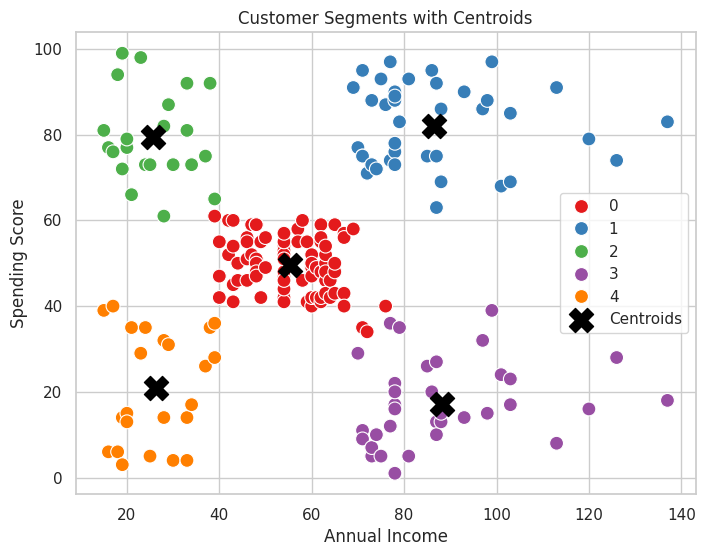

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income',
    y='Spending Score',
    hue='Cluster',
    palette='Set1',
    data=df1,
    s=100
)

# Plot centroids
plt.scatter(
    centroids_df['Annual Income'],
    centroids_df['Spending Score'],
    color='black',
    marker='X',
    s=300,
    label='Centroids'
)

plt.title("Customer Segments with Centroids")
plt.legend()
plt.show()

###Improve Visualization Quality

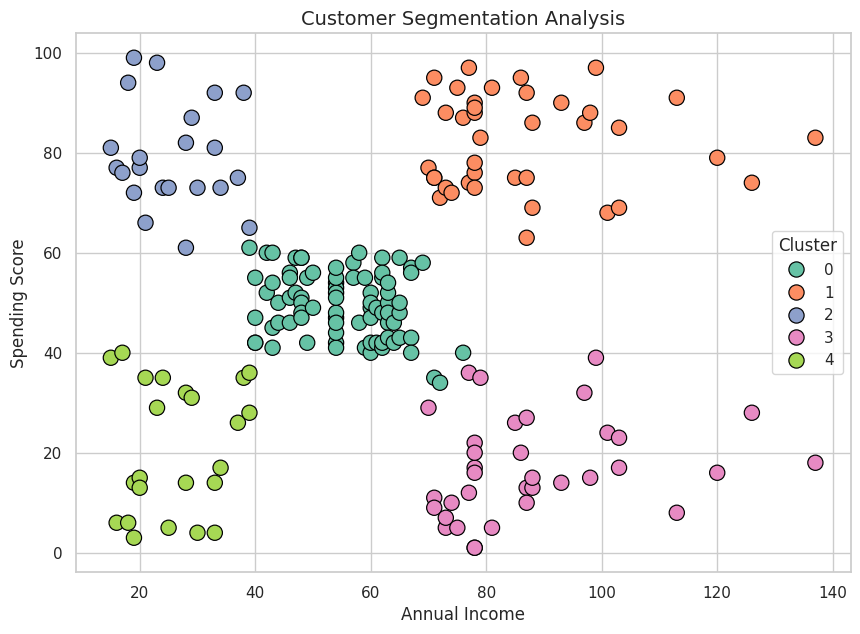

<Figure size 640x480 with 0 Axes>

In [30]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income',
    y='Spending Score',
    hue='Cluster',
    palette='Set2',
    data=df1,
    s=120,
    edgecolor='black'
)

plt.title("Customer Segmentation Analysis", fontsize=14)
plt.xlabel("Annual Income", fontsize=12)
plt.ylabel("Spending Score", fontsize=12)
plt.grid(True)
plt.show()

plt.savefig("clusters.png", bbox_inches='tight')

###Pairplot

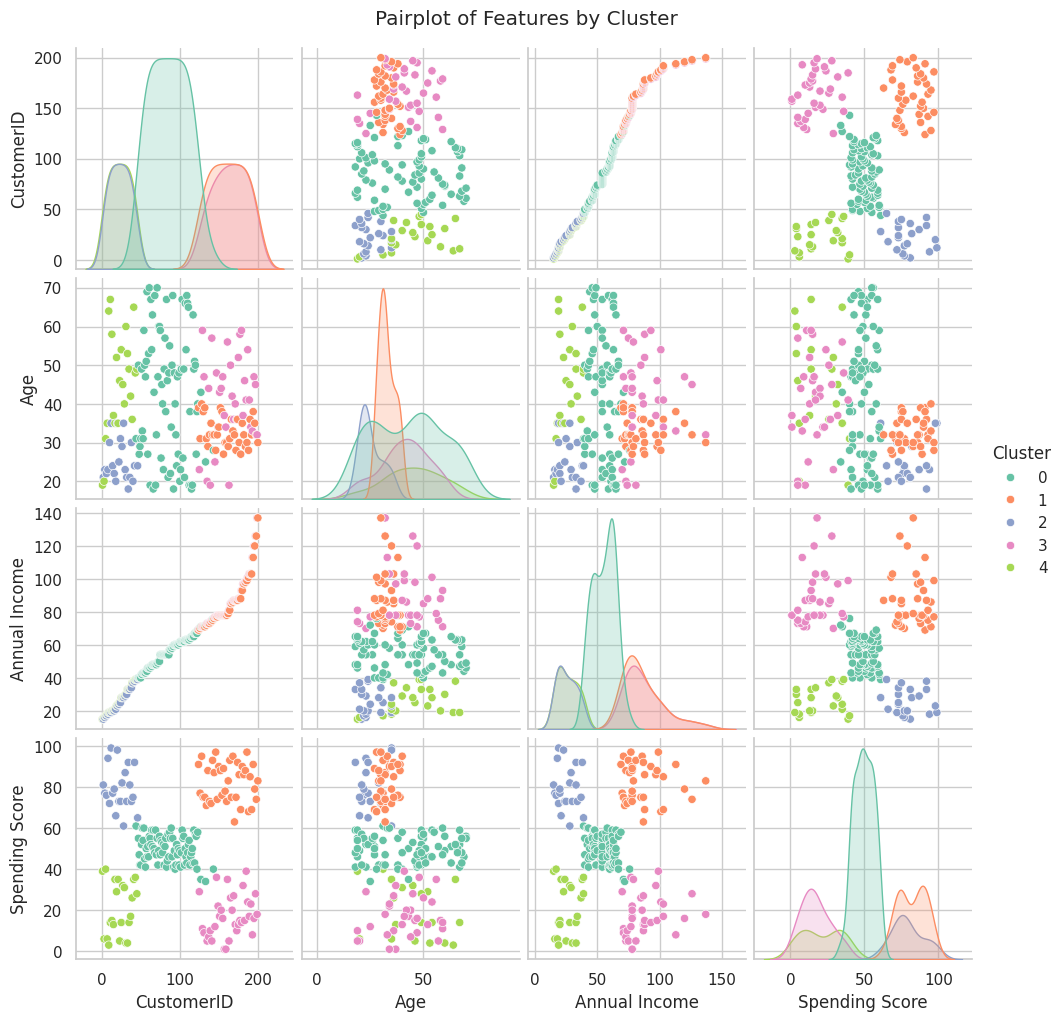

In [31]:
# Visualize relationships between features across clusters
sns.pairplot(df1, hue='Cluster', palette='Set2')
plt.suptitle("Pairplot of Features by Cluster", y=1.02)
plt.show()

##Explanation
###Optimal Cluster Selection:

The Elbow Method suggests an optimal number of clusters at k = 5, where the reduction in WCSS starts to slow down.

To further validate this, the Silhouette Score was calculated for multiple values of k.

The Silhouette Score for k = 5 is reasonably high, indicating:

Good separation between clusters

Compact grouping within clusters

Therefore, k = 5 is selected as the optimal number of clusters, balancing model simplicity and performance.

##Business Recommendations & Strategic Actions

Based on the customer segmentation analysis, the following business strategies are recommended for each segment:

Cluster 0 — Moderate Income, Moderate Spending

- Represents average customers with balanced behavior

- Strategy:
    - Maintain engagement through regular offers
    - Introduce loyalty programs to increase retention
    - Upsell mid-range products

Cluster 1 — High Income, Low Spending

- High purchasing power but low engagement

- Strategy:
    - Target with personalized marketing campaigns
    - Provide premium product recommendations
    - Use email/SMS campaigns to increase conversion

Cluster 2 — Low Income, High Spending

- Highly engaged but budget-conscious customers

- Strategy:
    - Offer discounts and promotions
    - Provide budget-friendly bundles
    - Focus on volume-based sales

Cluster 3 — Low Income, Low Spending

- Lowest value customer segment

- Strategy:
    - Minimize marketing spend
    - Target only during major sales events
    - Avoid heavy investment

Cluster 4 — High Income, High Spending (Premium Customers)

- Most valuable segment

- Strategy:
    - Offer VIP membership programs
    - Provide exclusive deals and early access
    - Focus on customer retention and experience

##Conclusion

- Customer segmentation using K-Means clustering successfully identified distinct customer groups based on income and spending behavior.

- The analysis reveals that not all customers contribute equally to revenue, highlighting the importance of targeted marketing.

- By focusing on high-value segments and optimizing strategies for each cluster, businesses can:

  - Increase revenue
  - Improve customer retention
  - Optimize marketing costs

- This project demonstrates how data-driven decision-making can significantly enhance business performance